# 4 · Limpieza de datos y features nuevas

## 4.0 — El punto de quiebre: LIMPIEZA DE DATOS
El panel tenía **25% de filas duplicadas** (explosión cartesiana de lat/lon por un join que
ignoró la provincia) y la etiqueta corrompida por mezclar departamentos homónimos. Corregirlo
(dedup + clave provincia, en `data.py`) **subió a TODOS +0.09–0.14 PR-AUC** — la mayor mejora
del proyecto.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

La progresión completa con las dos eras (exploración → limpieza → final):

In [2]:
explib.show(explib.tbl_journey())

,modelo,soja_PR_AUC,era
0,IForest (baseline),0.42,exploración
1,AE (mejor de 24 variantes),0.38,exploración
2,DAE (denoising),0.41,exploración
3,Híbrido AE-latente + IForest,0.31,exploración
4,VAE recon_prob (single),0.44,exploración ← salto del score
5,— LIMPIEZA DE DATOS (+0.09…0.14) —,NaN,punto de quiebre
6,IForest (limpio),0.51,panel limpio
7,VAE recon_prob single (limpio),0.56,panel limpio
8,VAE seed-ensemble (FINAL),0.59,panel limpio ★


## 4.1 — Features nuevas (NDVI, suelo, heladas, agro)
Para capturar el ~70% de anomalías con clima normal (NB 5), extrajimos por
departamento×campaña con Google Earth Engine: **NDVI-AVHRR** (1981+), **ERA5-Land** (humedad
de suelo + días de helada) y **agronómicas** (ventana crítica). Efecto, con test sets
emparejados:

In [3]:
explib.show(explib.tbl_features())

,features,VAE_seedens,IForest,nota
0,"base (limpio, sin features extra)",0.592,0.511,VAE / IForest
1,+ NDVI-AVHRR (1981+),0.561,0.503,redundante con clima
2,+ agronómicas (ventana crítica),0.422,0.421,"ayuda IForest, perjudica VAE"
3,+ ERA5 (suelo + heladas),0.580,0.542,"ayuda IForest, perjudica VAE"


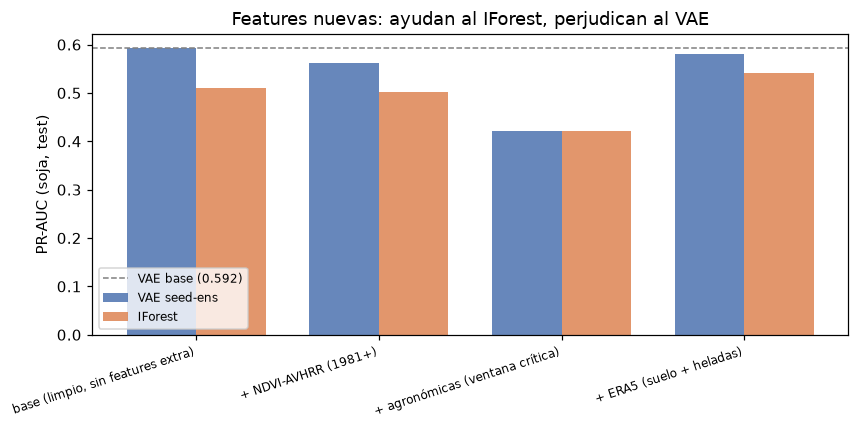

In [4]:
t = explib.tbl_features(); x = np.arange(len(t)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, t["VAE_seedens"], w, label="VAE seed-ens", color="#4C72B0", alpha=0.85)
ax.bar(x + w/2, t["IForest"], w, label="IForest", color="#DD8452", alpha=0.85)
ax.axhline(0.592, ls="--", color="gray", lw=1, label="VAE base (0.592)")
ax.set_xticks(x); ax.set_xticklabels(t["features"], rotation=18, ha="right", fontsize=8)
ax.set_ylabel("PR-AUC (soja, test)"); ax.legend(fontsize=8)
ax.set_title("Features nuevas: ayudan al IForest, perjudican al VAE"); plt.tight_layout(); plt.show()

**Conclusión:** ninguna feature extra supera al base con el VAE (diluyen el
`recon_prob`). Ayudan modestamente al IForest, pero IForest+ERA5 (0.542) sigue debajo del VAE
base (0.592).

**Artefacto cazado (lección de método):** un primer ERA5 dio 0.642 — era artefacto:
`frost_days`=0 en el norte → varianza-cero por depto → la normalización tiraba el 34% de los
departamentos → test sesgado. Se corrigió (std global de fallback). **Siempre validar que los
test sets coincidan antes de comparar.**